In [1]:
# -----------------------------
# Import libraries
# -----------------------------

from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import xgboost as xgb
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc
from sklearn.metrics import make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from string import ascii_uppercase
from geopy.distance import geodesic
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from xgboost import XGBRegressor
from scipy.stats import uniform
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [2]:
# -----------------------------
# Import local functions
# -----------------------------

import sys
import os

# Get the absolute path to your src folder
module_path = os.path.abspath(os.path.join('..', 'src'))

if module_path not in sys.path:
    sys.path.append(module_path)

from cleaning_and_helpers import plot_test_preds, evaluate_model_per_project, split_project, multioutput_rmse


In [3]:
# -----------------------------
# Set random seed, also for train test split set and models set seed within function
# -----------------------------
np.random.seed(1298)
seed = 1298

In [4]:
# -----------------------------
# Load .npy files with features and targets from each project
# -----------------------------

SI_X = np.load('../../pollenGeolocation_saved/SI_X_raw.npy')
SI_y = np.load('../../pollenGeolocation_saved/SI_y.npy')

FFAR_X = np.load('../../pollenGeolocation_saved/FFAR_X_raw.npy')
FFAR_y = np.load('../../pollenGeolocation_saved/FFAR_y.npy')

NCASI_X = np.load('../../pollenGeolocation_saved/NCASI_X_raw.npy')
NCASI_y = np.load('../../pollenGeolocation_saved/NCASI_y.npy')

In [5]:
# -----------------------------
# Train test split for each project
# ----------------------------- 
test_size = 0.20

# -----------------------------
# Split each project
# -----------------------------
SI_X_train, SI_X_test, SI_y_train, SI_y_test = split_project(SI_X, SI_y, test_size, seed)
NCASI_X_train, NCASI_X_test, NCASI_y_train, NCASI_y_test = split_project(NCASI_X, NCASI_y, test_size, seed)
FFAR_X_train, FFAR_X_test, FFAR_y_train, FFAR_y_test = split_project(FFAR_X, FFAR_y, test_size, seed)

# -----------------------------
# Concatenate train and test splits from all projects
# -----------------------------
X_train = np.concatenate([SI_X_train, NCASI_X_train, FFAR_X_train], axis=0)
y_train = np.concatenate([SI_y_train, NCASI_y_train, FFAR_y_train], axis=0)

X_test = np.concatenate([SI_X_test, NCASI_X_test, FFAR_X_test], axis=0)
y_test = np.concatenate([SI_y_test, NCASI_y_test, FFAR_y_test], axis=0)

# -----------------------------
# Standardize X and y using separate scalers for training and test set to prevent information
# leakage
# -----------------------------
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
y_train = sc_y.fit_transform(y_train)

X_test = sc_X.transform(X_test)
y_test = sc_y.transform(y_test)


In [6]:
# Project tracking 

# Add project IDs
SI_project_train = np.full(len(SI_X_train), 'Sky Islands')
SI_project_test  = np.full(len(SI_X_test), 'Sky Islands')

NCASI_project_train = np.full(len(NCASI_X_train), 'PNW Forests')
NCASI_project_test  = np.full(len(NCASI_X_test), 'PNW Forests')

FFAR_project_train = np.full(len(FFAR_X_train), 'CA Sunflowers')
FFAR_project_test  = np.full(len(FFAR_X_test), 'CA Sunflowers')

# Concatenate project labels
project_train = np.concatenate([SI_project_train, NCASI_project_train, FFAR_project_train], axis=0)
project_test  = np.concatenate([SI_project_test, NCASI_project_test, FFAR_project_test], axis=0)


In [7]:
## models

best_tuned_models = {
    "MultiTaskLasso": lambda: linear_model.MultiTaskLasso(alpha=0.08,
                                                          random_state=seed),
    "SVR": lambda: MultiOutputRegressor(SVR(C=2.847162213648956,
                                            gamma='auto',
                                            kernel='rbf')),
    "KNN": lambda: MultiOutputRegressor(KNeighborsRegressor(weights='uniform',
                                                            p=2,
                                                            n_neighbors=3,
                                                            algorithm='auto')),
    "DecisionTree": lambda: MultiOutputRegressor(DecisionTreeRegressor(min_samples_split=50,
                                                                       min_samples_leaf=1,
                                                                       max_leaf_nodes=None,
                                                                       max_features='sqrt',
                                                                       max_depth=None,
                                                                       random_state=seed)),
    "RandomForest": lambda: MultiOutputRegressor(RandomForestRegressor(n_estimators=200,
                                                                       min_samples_split=5,
                                                                       min_samples_leaf=1,
                                                                       max_features='log2',
                                                                       max_depth=None,
                                                                       random_state=seed)),
    "XGBoost": lambda: MultiOutputRegressor(XGBRegressor(subsample=0.8,
                                                         reg_lambda=1,
                                                         reg_alpha=1,
                                                         n_estimators=500,
                                                         min_child_weight=1,
                                                         max_depth=20,
                                                         learning_rate=0.3,
                                                         gamma=0,
                                                         colsample_bytree=0.8,
                                                         random_state=seed))
}



In [8]:

from sklearn.metrics import r2_score, root_mean_squared_error, median_absolute_error
from geopy.distance import geodesic
import numpy as np
import pandas as pd

def evaluate_model_per_project(
    name,
    model_class,
    X_train,
    y_train,
    X_test,
    y_test,
    scaler=None,
    project_test=None
):
    """
    Initialize, fit, predict, and evaluate a model.
    Returns full info for plotting: predictions, true values, distances, per-project metrics.
    """
    print(f"Evaluating {name}...")

    # Get a fresh model instance
    model = model_class()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # -----------------------------
    # Inverse transform if scaler provided
    # -----------------------------
    # if scaler is not None:
    #     y_test_unscaled = y_test
    #     preds_unscaled = scaler.inverse_transform(preds)
    # else:
    #     y_test_unscaled = y_test
    #     preds_unscaled = preds

    # -----------------------------
    # Compute distance errors
    # -----------------------------
    distances = np.array([
        geodesic(real, pred).kilometers
        for real, pred in zip(y_test, preds)
    ])

    # -----------------------------
    # Compute overall metrics
    # -----------------------------
    r2 = r2_score(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    mae = median_absolute_error(y_test, preds)
    avg_dist = np.mean(distances)
    se_dist = np.std(distances)

    results = {
        "model": name,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "avg_km_error": avg_dist,
        "se_km_error": se_dist,
        "y_test_unscaled": y_test,
        "preds_unscaled": preds,
        "distances": distances,
    }

    # -----------------------------
    # Add per-project metrics if given
    # -----------------------------
    if project_test is not None:
        df = pd.DataFrame({
            "y_true_lat": y_test[:, 0],
            "y_true_lon": y_test[:, 1],
            "y_pred_lat": preds[:, 0],
            "y_pred_lon": preds[:, 1],
            "project": project_test
        })

        project_metrics = []

        for project_id, group in df.groupby("project"):
            y_true_proj = group[["y_true_lat", "y_true_lon"]].values
            y_pred_proj = group[["y_pred_lat", "y_pred_lon"]].values

            r2_p = r2_score(y_true_proj, y_pred_proj)
            rmse_p = root_mean_squared_error(y_true_proj, y_pred_proj)
            mae_p = median_absolute_error(y_true_proj, y_pred_proj)
            distances_p = [
                geodesic(real, pred).kilometers
                for real, pred in zip(y_true_proj, y_pred_proj)
            ]
            avg_dist_p = np.mean(distances_p)
            se_dist_p = np.std(distances_p)

            project_metrics.append({
                "project": project_id,
                "r2": r2_p,
                "rmse": rmse_p,
                "mae": mae_p,
                "avg_km_error": avg_dist_p,
                "se_km_error": se_dist_p
            })

        results["per_project"] = project_metrics
        results["project_test"] = project_test

    return results


In [9]:
results = {}

for name, model_func in best_tuned_models.items():
    result = evaluate_model_per_project(
        name,
        model_func,
        X_train,
        y_train,
        X_test,
        y_test,
        project_test=project_test  # optional if you have per-project splits
    )
    results[name] = result


Evaluating MultiTaskLasso...
Evaluating SVR...
Evaluating KNN...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating XGBoost...


In [10]:
all_distances = []
df_models = []
project_labels = None  # <-- use None not []

for name, result in results.items():
    distances = result["distances"]
    all_distances.extend(distances)
    df_models.append((name, distances))
    
    if project_labels is None:
        project_labels = result.get("project_test", None)

if project_labels is None:
    raise ValueError("You need to pass project_test so we can label projects!")


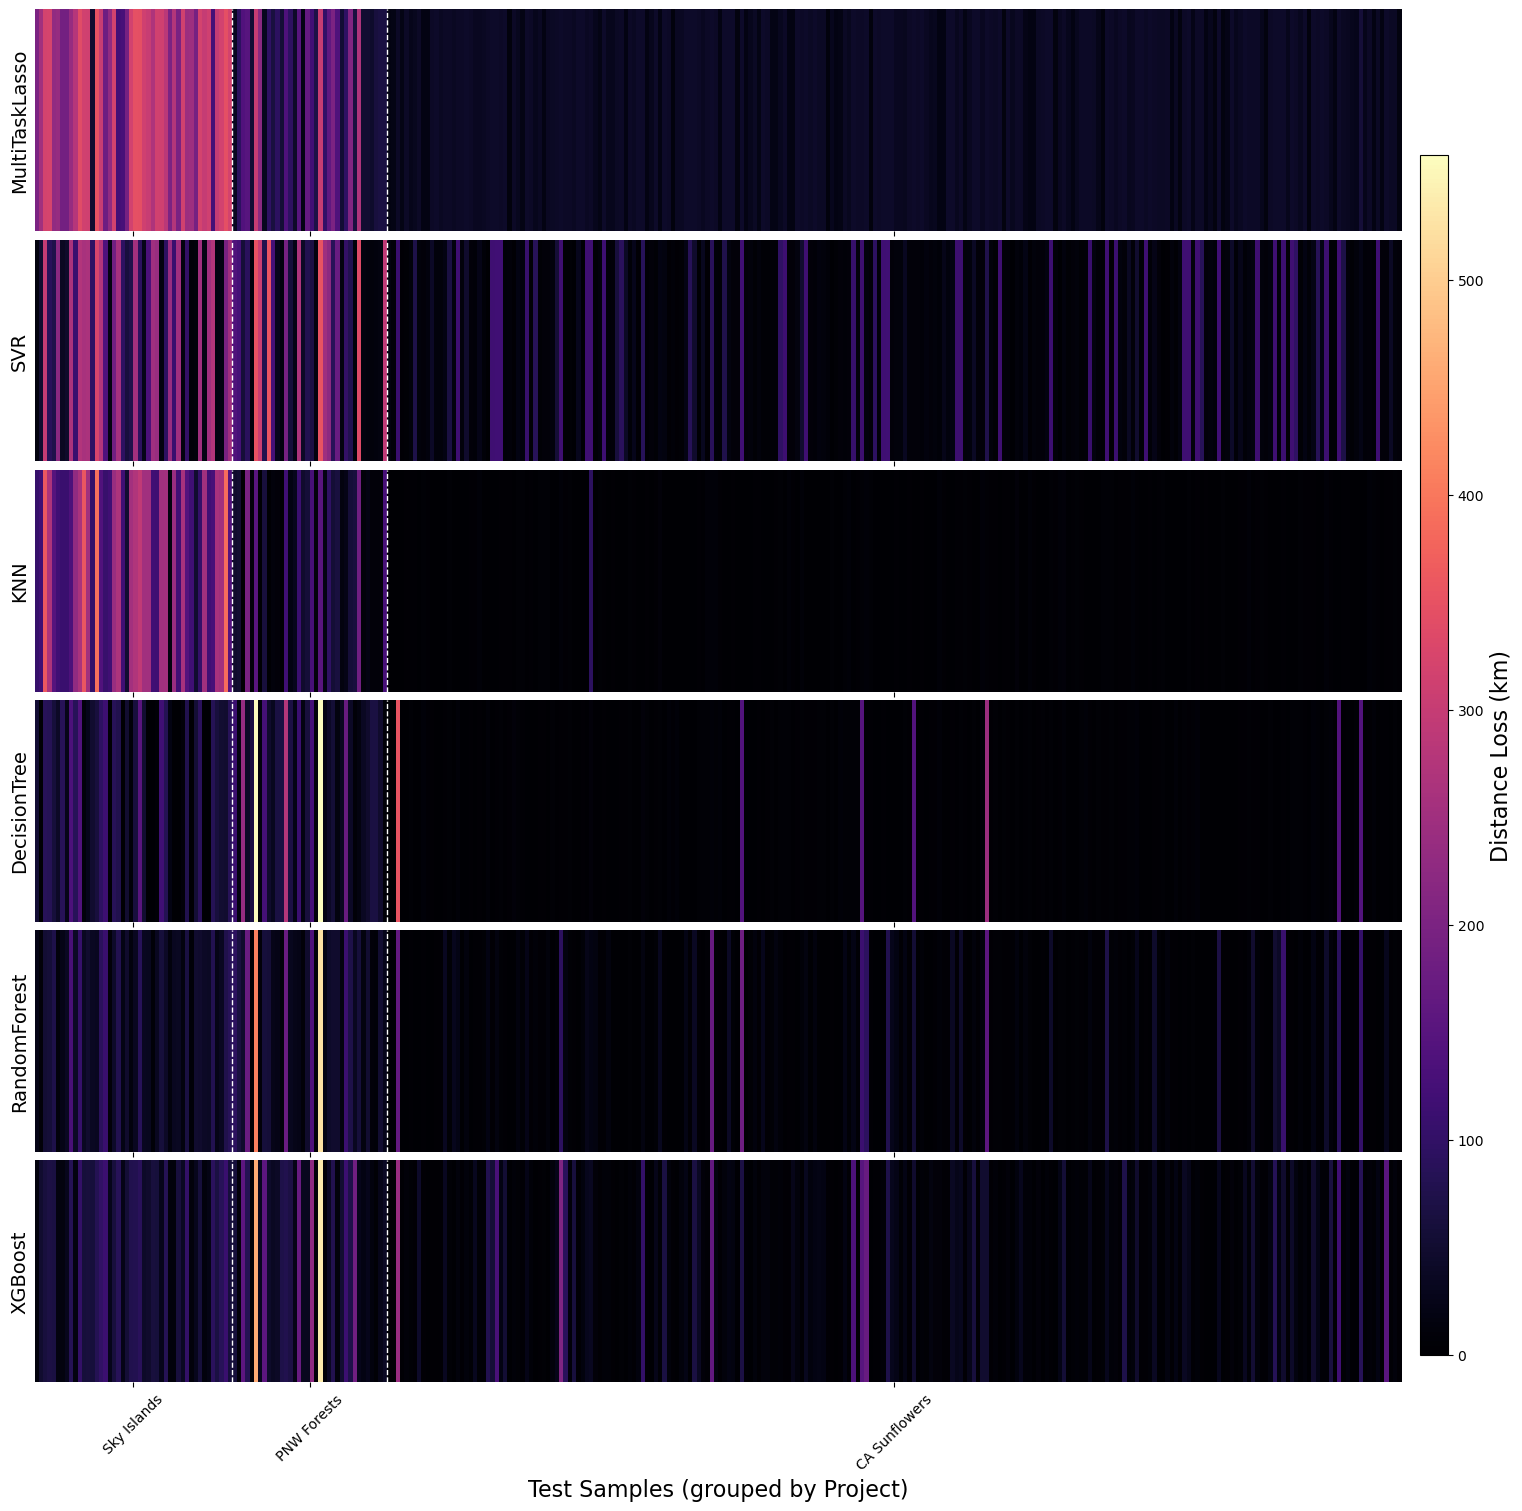

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# -----------------------------------------------
# Get distances & a single project label vector
# -----------------------------------------------
all_distances = []
df_models = []
project_labels = None  # use None, not []

for name, result in results.items():
    distances = result["distances"]
    all_distances.extend(distances)
    df_models.append((name, distances))

    # Get project_test from the first result that has it
    if project_labels is None and "project_test" in result:
        project_labels = result["project_test"]

if project_labels is None:
    raise ValueError("You need to pass project_test so we can label projects!")

projects = np.array(project_labels)

# -----------------------------------------------
# Compute breakpoints + midpoints for labels
# -----------------------------------------------
unique_projects = []
breakpoints = []

prev_proj = None
for i, proj in enumerate(projects):
    if proj != prev_proj:
        unique_projects.append(proj)
        if prev_proj is not None:
            breakpoints.append(i)
        prev_proj = proj

breakpoints.append(len(projects))  # Add final break

midpoints = []
for start, end in zip([0] + breakpoints[:-1], breakpoints):
    midpoints.append((start + end) // 2)

# -----------------------------------------------
# Set up figure
# -----------------------------------------------
global_vmin = np.min(all_distances)
global_vmax = np.max(all_distances)
norm = mcolors.Normalize(vmin=global_vmin, vmax=global_vmax)

fig, axes = plt.subplots(
    len(df_models), 1, figsize=(14, 15),
    sharex=True, constrained_layout=True
)
cbar_ax = fig.add_axes([1.01, 0.1, 0.02, 0.8])

# Make background white and text black
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(colors='black')         # tick labels
    for spine in ax.spines.values():
        spine.set_color('black')           # axes border
    ax.title.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.xaxis.label.set_color('black')

cbar_ax.set_facecolor('white')

# -----------------------------------------------
# Plot heatmaps with vertical lines
# -----------------------------------------------
for ax, (model_name, distances) in zip(axes, df_models):
    distances_2d = np.expand_dims(distances, axis=0)

    sns.heatmap(
        distances_2d,
        ax=ax,
        cmap="magma",
        cbar=False,
        vmin=global_vmin,
        vmax=global_vmax,
        xticklabels=False,  # we'll add our own
        yticklabels=False
    )
    ax.set_ylabel(model_name, fontsize=14)

    # Vertical lines for project boundaries
    for bp in breakpoints[:-1]:
        ax.axvline(x=bp, color="white", linestyle="--", lw=1)

# -----------------------------------------------
# Add project labels along x-axis of the bottom plot
# -----------------------------------------------
axes[-1].set_xlabel("Test Samples (grouped by Project)", fontsize=16)
axes[-1].set_xticks(midpoints)
axes[-1].set_xticklabels(unique_projects, fontsize=10, rotation=45)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Distance Loss (km)', fontsize=16, color='black')
# Make colorbar text and ticks black
cbar.ax.yaxis.set_tick_params(color='black', labelcolor='black')
for spine in cbar.ax.spines.values():
    spine.set_color('black')

plt.savefig("../../pollenGeolocation_saved/figs/raw_sample_compare_all_mods_w_projects.pdf",
            format="pdf")
plt.show()


In [33]:
def plot_test_preds(y_test, preds, scaler, model_type, ax, norm, r2, rmse):
    # Back-transform for plotting real vs. predicted coords
    unscaled_y_test = scaler.inverse_transform(y_test)
    unscaled_preds = scaler.inverse_transform(preds)

    lat_test, lon_test = unscaled_y_test[:, 0], unscaled_y_test[:, 1]
    lat_pred, lon_pred = unscaled_preds[:, 0], unscaled_preds[:, 1]

    distances = np.array([
        geodesic((lat1, lon1), (lat2, lon2)).kilometers
        for lat1, lon1, lat2, lon2 in zip(lat_test, lon_test, lat_pred, lon_pred)
    ])

    sorted_indices = np.argsort(distances)
    lat_pred, lon_pred = lat_pred[sorted_indices], lon_pred[sorted_indices]
    lat_test_sorted, lon_test_sorted = lat_test[sorted_indices], lon_test[sorted_indices]
    distances = distances[sorted_indices]

    # SCATTER plots
    ax.scatter(lon_test_sorted, lat_test_sorted, marker='*', s=350, label='Real',
               color='gold', edgecolors='black', linewidths=0.8)
    sc = ax.scatter(lon_pred, lat_pred, c=distances, cmap='magma', alpha=0.9,
                    label='Predicted', edgecolors='black', linewidths=0.6, norm=norm)

    # Style, labels, legend...
    ax.set_facecolor('white')

    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

    for spine in ax.spines.values():
        spine.set_color('black')
        ax.grid(True, linestyle='--', color='lightgray', linewidth=0.5)
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        leg = ax.legend(frameon=True, fontsize=10)
        leg.get_frame().set_facecolor('white')
        leg.get_frame().set_edgecolor('black')

    for text in leg.get_texts():
        text.set_color('black')
        #ax.invert_xaxis()
        #ax.invert_yaxis()

    # Use pre-computed r2 and mse
    ax.text(
        0.02, 0.25,
        f'{model_type}\n$R^2$: {r2:.2f}\nRMSE: {rmse:.2f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        color='black',
        bbox=dict(
            boxstyle='round,pad=0.3',
            edgecolor='gray',
            facecolor='white')
    )

    return sc, distances


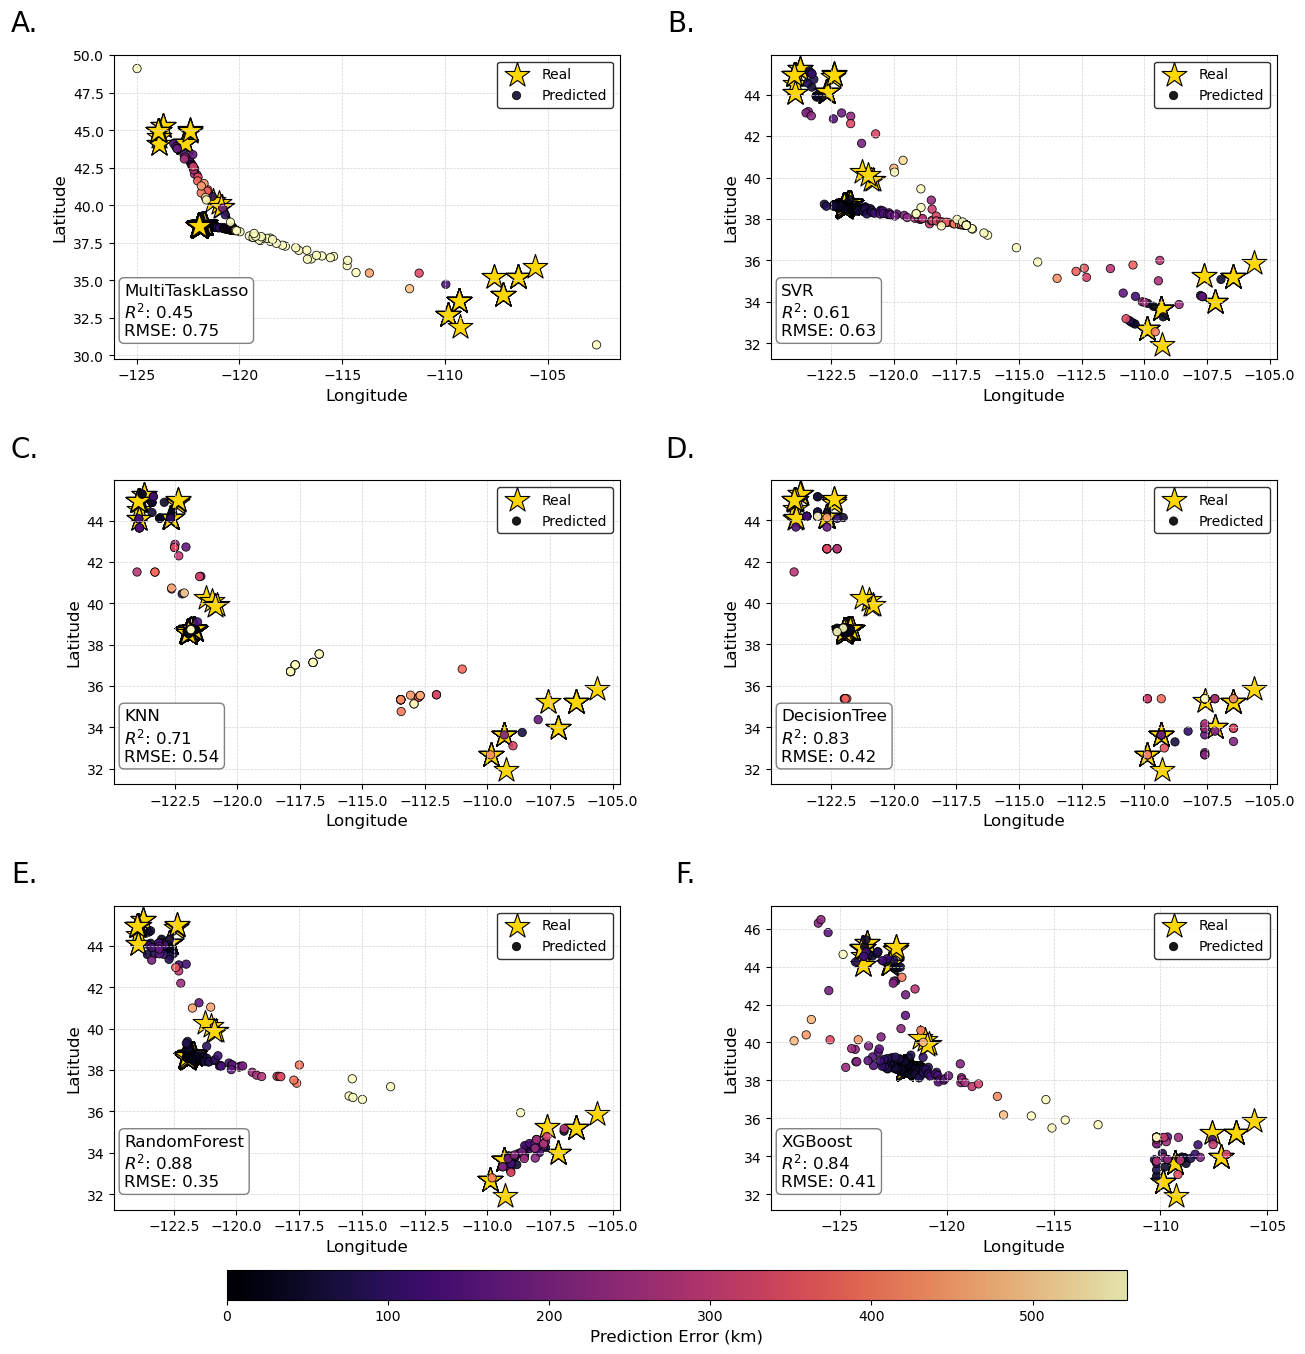

In [35]:


# Create a 3x2 grid of subplots with adjusted spacing
fig, axes = plt.subplots(3, 2, figsize=(15, 15), facecolor='white')  # Increased width for better spacing
axes = axes.flatten()  # Flatten the 2D array for easy iteration

sc_list = []  # Store scatter objects for colorbar reference

# Iterate over method_dict to access both model_type and associated preds
sc_list = []

for i, (model_type, model_result) in enumerate(results.items()):
    preds = model_result["preds_unscaled"]
    r2 = model_result["r2"]
    rmse = model_result["rmse"]

    ax = axes[i]
    sc, _ = plot_test_preds(y_test, preds, sc_y, model_type, ax=ax, norm=norm, r2=r2, rmse=rmse)
    sc_list.append(sc)

    ax.text(
        -0.15, 1.15,
        f"{ascii_uppercase[i]}.",
        transform=ax.transAxes,
        color='black',
        fontsize=20,
        va='top',
        ha='right'
    )



# Adjust subplot spacing to create a small gap between columns
plt.subplots_adjust(wspace=0.3, hspace=0.4)  # `wspace` increases horizontal gap

# Add a single horizontal colorbar across the bottom
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
cbar = plt.colorbar(sc_list[-1], cax=cbar_ax, orientation="horizontal")

cbar.set_label('Prediction Error (km)', fontsize=12, color='black')
cbar.ax.tick_params(colors='black', labelcolor='black')
cbar.outline.set_edgecolor('black')


# Save the plot as a PDF
plt.savefig("../../pollenGeolocation_saved/figs/raw_real_vs_pred_scatterplots_normalized.pdf", format="pdf")

plt.show()


In [ ]:
## WIP Diversity and evenness
# Keep the raw relative abundance values before scaling
X_train_raw = np.concatenate([SI_X_train, NCASI_X_train, FFAR_X_train], axis=0)
X_test_raw  = np.concatenate([SI_X_test, NCASI_X_test, FFAR_X_test], axis=0)

import pandas as pd

# Suppose you know the pollen DNA feature names
pollen_cols = [f"ASV_{i}" for i in range(X_train_raw.shape[1])]

# Combine train and test if you want diversity metrics for all samples
X_all_raw = np.concatenate([X_train_raw, X_test_raw], axis=0)
project_all = np.concatenate([project_train, project_test], axis=0)

df = pd.DataFrame(X_all_raw, columns=pollen_cols)
df['project'] = project_all


In [ ]:
import numpy as np

def shannon_diversity(rel_abundances):
    """Compute Shannon diversity, ignoring zeros and NaNs"""
    rel_abundances = np.asarray(rel_abundances, dtype=float)
    rel_abundances = rel_abundances[np.isfinite(rel_abundances)]  # drop NaNs
    rel_abundances = rel_abundances[rel_abundances > 0]           # drop zeros
    if len(rel_abundances) == 0:
        return 0
    return -np.sum(rel_abundances * np.log(rel_abundances))

def pielou_evenness(shannon, richness):
    """Compute Pielou's evenness"""
    if richness > 1 and np.isfinite(shannon):
        return shannon / np.log(richness)
    else:
        return 0


In [ ]:
diversity_results = []

for i, row in df.iterrows():
    rel_abund = row[pollen_cols].values
    richness = np.sum(rel_abund > 0)
    shannon  = shannon_diversity(rel_abund)
    evenness = pielou_evenness(shannon, richness)
    diversity_results.append({
        'project': row['project'],
        'richness': richness,
        'shannon': shannon,
        'evenness': evenness
    })

div_df = pd.DataFrame(diversity_results)


In [ ]:
project_summary = div_df.groupby('project').agg(
    richness_mean=('richness', 'mean'),
    richness_sd=('richness', 'std'),
    shannon_mean=('shannon', 'mean'),
    shannon_sd=('shannon', 'std'),
    evenness_mean=('evenness', 'mean'),
    evenness_sd=('evenness', 'std')
).reset_index()

print(project_summary)


In [ ]:
# WIP 7-3
# Example: use one model's results
model_name = "RandomForest"
model_result = results[model_name]

# Get the per-sample distances and project labels
distances = model_result["distances"]
project_labels = model_result["project_test"]

# Build DataFrame
geo_df = pd.DataFrame({
    "project": project_labels,
    "geodesic_error_km": distances
})


In [ ]:
# If they’re in the same order, just concat
combined_df = pd.concat([geo_df, div_df[["richness", "shannon", "evenness"]]], axis=1)


In [ ]:
import statsmodels.api as sm

X = combined_df[['richness', 'shannon', 'evenness']]
X = sm.add_constant(X)
y = combined_df['geodesic_error_km']

model = sm.OLS(y, X).fit()
print(model.summary())


In [ ]:
# final_df = project_summary.merge(df_per_project, on='project', how='left')


In [ ]:
# TODO investigate the identity of pollen across projects, rerun mods with the taxonomy 
# TODO shap feature importance

In [ ]:
rf =MultiOutputRegressor(RandomForestRegressor(n_estimators = 200,
                          min_samples_split = 5,
                          min_samples_leaf = 1, 
                          max_features = 'log2', 
                          max_depth = None)) 

rf = rf.fit(X_train,y_train)
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

In [ ]:
names = np.load('../../pollenGeolocation_saved/X_columns_raw.npy', allow_pickle=True)

In [ ]:
all_importances = np.vstack([estimator.feature_importances_ for estimator in rf.estimators_]).T
importance_df = pd.DataFrame(all_importances, index=names, columns=[f"Output_{i}" for i in range(len(rf.estimators_))])
importance_df


In [ ]:
# Get top 25 for each output
top_n = 25
top_features = {}

for col in importance_df.columns:
    top_features[col] = (
        importance_df[col]
        .sort_values(ascending=False)
        .head(top_n)
    )


In [ ]:
import matplotlib.pyplot as plt

# Create subplots for 2 outputs
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for i, (output_name, importances) in enumerate(top_features.items()):
    ax = axes[i]
    importances = importances.sort_values()  # So the bars go from low to high
    ax.barh(importances.index, importances.values)
    ax.set_title(f"Top {top_n} Features for {output_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()


In [ ]:
# Union of all top features
all_top_features = set()
for feat_series in top_features.values():
    all_top_features.update(feat_series.index)

print(f"Total unique features to BLAST: {len(all_top_features)}")


In [ ]:
clean_top_features = {name.replace("RBCL:", "") for name in all_top_features}


In [ ]:
# Make a list with unique labels
labeled_seqs = [
    (f"Feature_{i+1}", seq) for i, seq in enumerate(clean_top_features)
]

print(labeled_seqs)

In [ ]:
pwd

In [ ]:
from Bio.Blast import NCBIWWW, NCBIXML
import pandas as pd
import time

results = []

for i, (label, seq) in enumerate(labeled_seqs):
    print(f"BLASTing {i+1}/{len(labeled_seqs)}: {label}...")
    
    try:
        result_handle = NCBIWWW.qblast(
            program="blastn",
            database="nt",
            sequence=seq,
            hitlist_size=10,   # limit top hits
            expect=0.001,      # stricter cutoff
            filter="L"         # mask low-complexity
        )
        
        # Save raw result for reproducibility
        with open(f"../data/raw/blast_xmls_top_feats/blast_result_{label}.xml", "w") as out_handle:
            out_handle.write(result_handle.read())
        result_handle.close()

        # Reopen to parse
        with open(f"../data/raw/blast_xmls_top_feats/blast_result_{label}.xml") as result_handle:
            blast_record = NCBIXML.read(result_handle)

        top_hit = None
        for alignment in blast_record.alignments:
            for hsp in alignment.hsps:
                top_hit = {
                    "Label": label,
                    "TopHitTitle": alignment.title,
                    "Evalue": hsp.expect,
                    "Identity": hsp.identities / alignment.length
                }
                break
            break

        if top_hit:
            results.append(top_hit)
        else:
            results.append({
                "Label": label,
                "TopHitTitle": "No hit",
                "Evalue": None,
                "Identity": None
            })

    except Exception as e:
        print(f"Error with {label}: {e}")
        results.append({
            "Label": label,
            "TopHitTitle": "Error",
            "Evalue": None,
            "Identity": None
        })

    time.sleep(2)  # Polite pause for NCBI

# Convert to DataFrame
blast_hits_df = pd.DataFrame(results)
print(blast_hits_df)

# Save hits to CSV
blast_hits_df.to_csv("../data/raw/raw_blast_hits_summary.csv", index=False)
print("Saved hits summary to blast_hits_summary.csv")


In [ ]:
blast_hits_df

In [ ]:
blast_hits_df.TopHitTitle[0]

In [ ]:
def extract_species(title):
    # Remove GI info if any
    parts = title.split('|')
    if len(parts) > 2:
        after_pipe = parts[-1]  # grab last section
    else:
        after_pipe = title

    # Get first two words
    words = after_pipe.strip().split()
    if len(words) >= 2:
        return f"{words[0]} {words[1]}"
    else:
        return None

blast_hits_df["Species"] = blast_hits_df["TopHitTitle"].apply(extract_species)


In [ ]:
blast_hits_df

In [ ]:
# Suppose your blast_hits_df has:
#   Label          Species
#   RBCL:ASV1      Arabidopsis thaliana
#   RBCL:ASV2      Poa annua
#   ...

# Or, if you used generic Feature_1 labels, keep your own mapping of ASV -> Feature_X

species_map = blast_hits_df[["Label", "Species"]].set_index("Label")


In [ ]:
# Map the index (which is feature names)
importance_df["Species"] = importance_df.index.map(species_map["Species"])

# Fill any missing with the original ID for clarity
importance_df["Label"] = [
    f"{species if pd.notnull(species) else feat}"
    for feat, species in zip(importance_df.index, importance_df["Species"])
]
importance_df = importance_df.iloc[:,:-2]
importance_df

In [ ]:
top_features = {}

for col in importance_df.columns[:-2]:  # exclude the Species & Label cols
    top = (
        importance_df[col]
        .sort_values(ascending=False)
        .head(top_n)
    )
    labels = importance_df.loc[top.index, "Label"]
    top.index = labels  # Use species names instead of ASV IDs
    top_features[col] = top


In [ ]:
# Get a DataFrame of original features
features_df = pd.DataFrame({
    "FeatureID": importance_df.index,
})

# Remove 'RBCL:' prefix to get just the sequence
features_df["Sequence"] = features_df["FeatureID"].str.replace("RBCL:", "")
#features_df


In [ ]:
labeled_df = pd.DataFrame(labeled_seqs, columns=["Label", "Sequence"])
#labeled_df

In [ ]:
# Merge to add the Feature_# label
features_labeled = features_df.merge(labeled_df, on="Sequence", how="left")

# Merge to add Species from your BLAST hits
features_labeled = features_labeled.merge(
    blast_hits_df[["Label", "Species"]],
    on="Label",
    how="left"
)
#features_labeled

In [ ]:
species_lookup = features_labeled.set_index("FeatureID")["Species"]

importance_df["Species"] = importance_df.index.map(species_lookup)

# Fallback to raw FeatureID if Species missing
importance_df["Label"] = importance_df.apply(
    lambda row: row["Species"] if pd.notnull(row["Species"]) else row.name,
    axis=1
)
# Rename the output columns
importance_df = importance_df.rename(columns={
    "Output_0": "Latitude",
    "Output_1": "Longitude"
})
importance_df.columns


In [ ]:
top_features = {}
for col in importance_df.columns[:-2]:  # exclude Species, Label cols
    top = importance_df[col].sort_values(ascending=False).head(25)
    labels = importance_df.loc[top.index, "Label"]
    top.index = labels
    top_features[col] = top


In [ ]:
print(top_features.keys())


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(top_features), figsize=(16, 8), sharey=True)

for i, (output_name, importances) in enumerate(top_features.items()):
    ax = axes[i]
    importances = importances.sort_values()
    ax.barh(importances.index, importances.values)
    ax.set_title(f"Top 25 Features for {output_name}")
    ax.set_xlabel("Importance")
    if i == 0:
        ax.set_ylabel("Species")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
names = np.load('X_cols.npy', allow_pickle = True)
#reg= ExtraTreesRegressor()
rf.fit(X_train,y_train)
importance = rf.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(rf.feature_importances_, index=names)
print('Most Important Features')
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
#names = np.load('X_cols.npy', allow_pickle = True)
#reg= ExtraTreesRegressor()
#rf.fit(X_train,y_train)
importance = rf.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(rf.feature_importances_, index=names)
print('Most Important Features')
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
names = np.load('X_cols.npy', allow_pickle = True)
#reg= ExtraTreesRegressor()
rf.fit(X_train,y_train)
importance = rf.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(rf.feature_importances_, index=names)
print('Most Important Features')
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
import shap
import numpy as np

# 1. Extract your MultiOutputRegressor
# Example:
# rf_model = rf_result["estimator"]

# 2. Loop over outputs (e.g., lat, lon)
shap_values_list = []

for i, estimator in enumerate(rf.estimators_):
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    shap_values_list.append(shap_values)

# 3. Average absolute SHAP values if you want a single importance score
mean_shap = np.mean(np.abs(np.stack(shap_values_list)), axis=0)

# 4. Wrap in DataFrame
shap_df = pd.DataFrame(mean_shap, columns=X_cols)
shap_df["project"] = project_test

# 5. Group by project
project_feature_importance = (
    shap_df.groupby("project")
    .agg(lambda x: np.mean(np.abs(x)))
    .transpose()
)

print(project_feature_importance)
